In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data
local_file = 'train.csv'
if os.path.exists(local_file):
    df = pd.read_csv(local_file)
else:
    from sklearn.datasets import fetch_openml

    openml_data = fetch_openml('house_prices', version=1, as_frame=True)
    df = pd.concat(
        [openml_data.data, pd.Series(openml_data.target, name=openml_data.target.name)],
        axis=1,
    )

# 2. Select columns (11 numerical features + 5 categorical features + target)
num_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 
                'YearBuilt', 'YearRemodAdd', 'LotArea']
cat_features = ['Neighborhood', 'BldgType', 'HouseStyle', 'ExterQual', 'KitchenQual']
target = 'SalePrice'

df_selected = df[num_features + cat_features + [target]].copy()
print(f"Dataset shape: {df_selected.shape}")


Dataset shape: (1460, 17)


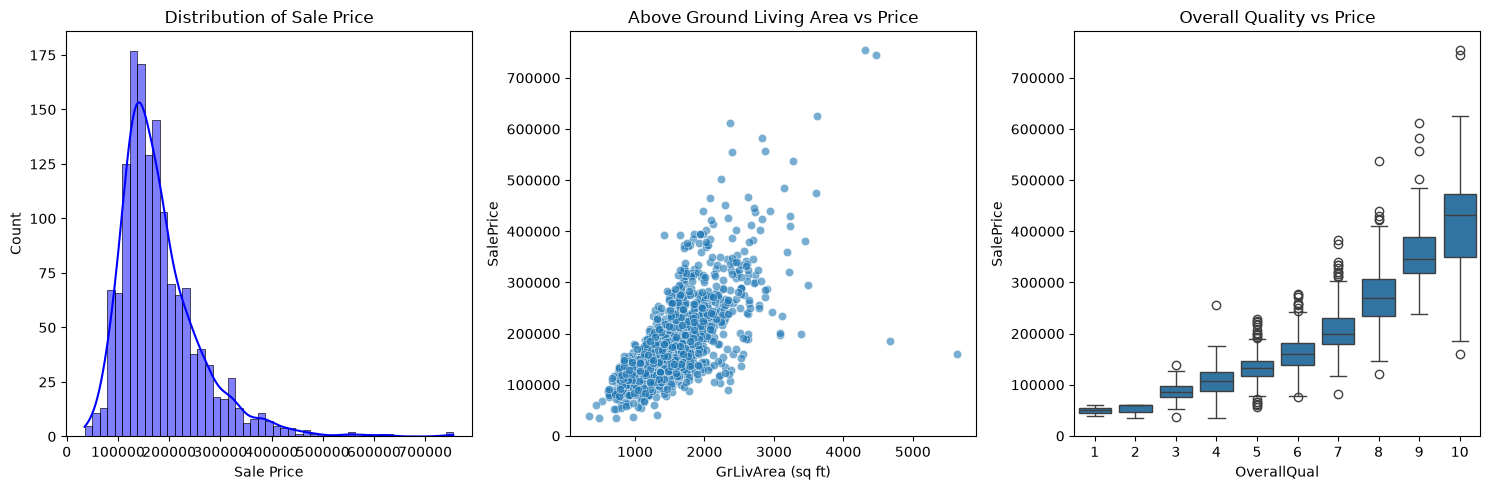

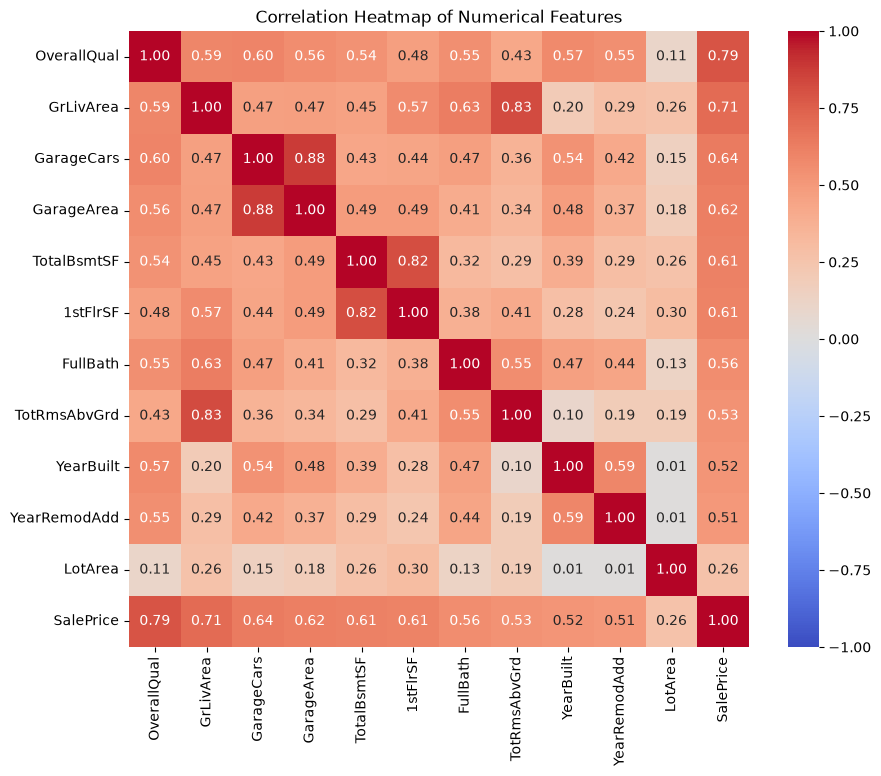

In [9]:
plt.figure(figsize=(15, 5))

# 1. Distribution of Target Variable
plt.subplot(1, 3, 1)
sns.histplot(df_selected['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')

# 2. GrLivArea vs SalePrice (Size vs Price)
plt.subplot(1, 3, 2)
sns.scatterplot(x=df_selected['GrLivArea'], y=df_selected['SalePrice'], alpha=0.6)
plt.title('Above Ground Living Area vs Price')
plt.xlabel('GrLivArea (sq ft)')

# 3. OverallQual vs SalePrice (Quality vs Price)
plt.subplot(1, 3, 3)
sns.boxplot(x=df_selected['OverallQual'], y=df_selected['SalePrice'])
plt.title('Overall Quality vs Price')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap (Numerical only)
plt.figure(figsize=(10, 8))
corr_matrix = df_selected[num_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [10]:
X = df_selected.drop(columns=[target])
y = df_selected[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Full Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [11]:
# Define hyperparameter space
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best Hyperparameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}


Baseline Test RMSE: $28,466.53
Baseline Test R2 Score: 0.8944


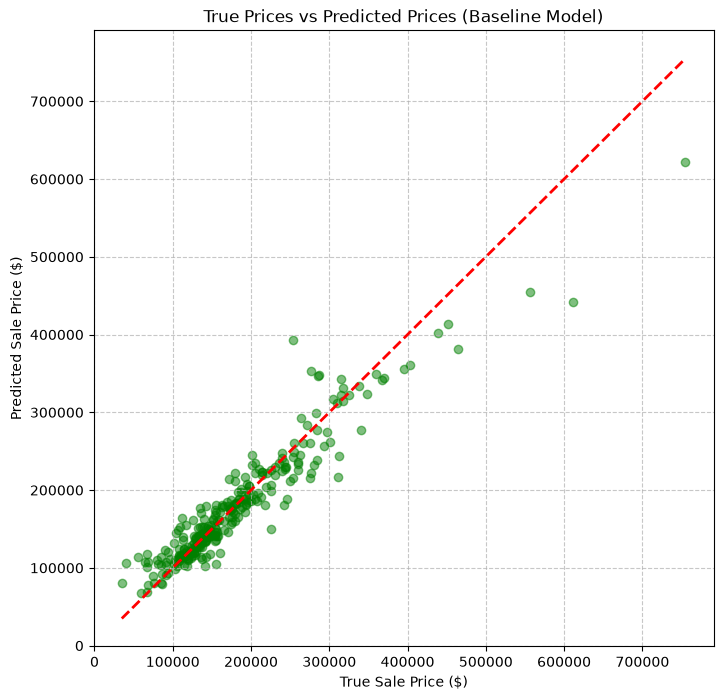

In [12]:
# Predict and evaluate
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline Test RMSE: ${rmse:,.2f}")
print(f"Baseline Test R2 Score: {r2:.4f}")

# Visualization: True vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line
plt.title('True Prices vs Predicted Prices (Baseline Model)')
plt.xlabel('True Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
def engineer_features(data):
    df_fe = data.copy()
    # 1. Total Square Footage
    df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe.get('2ndFlrSF', 0)
    
    # 2. House Age at time of sale (assuming dataset goes up to 2010)
    df_fe['HouseAge'] = 2010 - df_fe['YearBuilt']
    
    # 3. Was it remodeled? (Binary)
    df_fe['IsRemodeled'] = (df_fe['YearBuilt'] != df_fe['YearRemodAdd']).astype(int)
    
    return df_fe

# Apply FE to original data
df_fe = engineer_features(df_selected)

# Update feature lists
new_num_features = num_features + ['TotalSF', 'HouseAge', 'IsRemodeled']
X_fe = df_fe.drop(columns=[target])
y_fe = df_fe[target]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

# Create updated preprocessor
preprocessor_fe = ColumnTransformer(transformers=[
    ('num', num_transformer, new_num_features),
    ('cat', cat_transformer, cat_features)
])

pipeline_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestRegressor(**{k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}, random_state=42))
])

# Fit and evaluate new pipeline
pipeline_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = pipeline_fe.predict(X_test_fe)

rmse_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_fe))
r2_fe = r2_score(y_test_fe, y_pred_fe)

print(f"Feature Engineered Test RMSE: ${rmse_fe:,.2f}")
print(f"Feature Engineered Test R2 Score: {r2_fe:.4f}")
print(f"RMSE Improvement: ${rmse - rmse_fe:,.2f}")

Feature Engineered Test RMSE: $28,542.68
Feature Engineered Test R2 Score: 0.8938
RMSE Improvement: $-76.15
